**Importing the Libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import warnings
warnings.filterwarnings("ignore")

**Loading the Dataset**

In [2]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Getting to know the dataset**

In [3]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [4]:
df.drop(["Id"], axis =1, inplace = True)

In [5]:
df["Species"] = df["Species"].str.replace("Iris-", "")

In [6]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


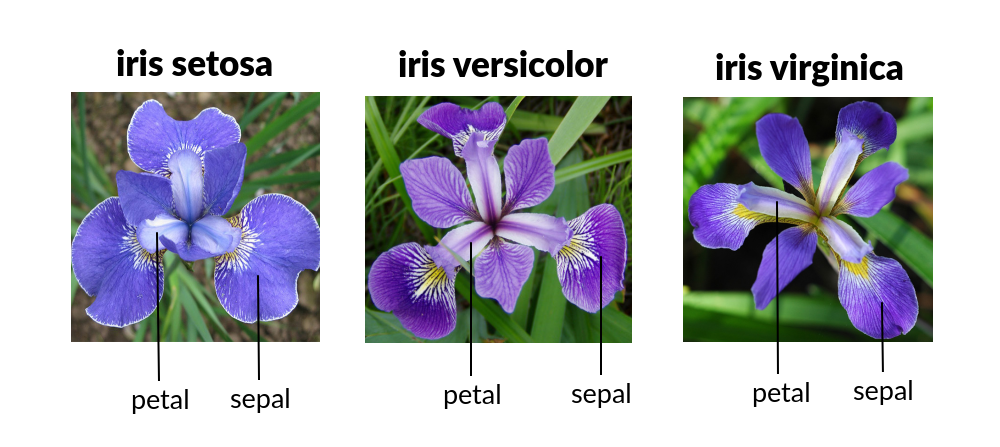

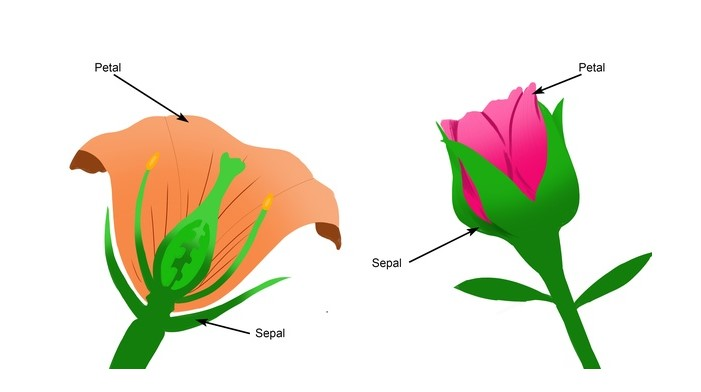

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**EDA**

In [8]:
sns.pairplot(df, hue="Species", height = 2.75);

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
df["Species_Num"] = df["Species"]

In [11]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_Num
0,5.1,3.5,1.4,0.2,setosa,setosa
1,4.9,3.0,1.4,0.2,setosa,setosa
2,4.7,3.2,1.3,0.2,setosa,setosa
3,4.6,3.1,1.5,0.2,setosa,setosa
4,5.0,3.6,1.4,0.2,setosa,setosa


In [12]:
df["Species_Num"] = df["Species_Num"].str.replace("setosa", "1")
df["Species_Num"] = df["Species_Num"].str.replace("versicolor", "2")
df["Species_Num"] = df["Species_Num"].str.replace("virginica", "3")

In [13]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_Num
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
 5   Species_Num    150 non-null    object 
dtypes: float64(4), object(2)
memory usage: 7.2+ KB


In [15]:
df["Species_Num"] = pd.to_numeric(df["Species_Num"], downcast = "integer")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
 5   Species_Num    150 non-null    int8   
dtypes: float64(4), int8(1), object(1)
memory usage: 6.1+ KB


In [17]:
plt.figure(figsize = (15,9))
sns.heatmap(df.corr(numeric_only=True), cmap='Spectral', annot = True);

In [18]:
df.drop(["PetalLengthCm", "Species_Num"], axis = 1, inplace = True)

In [19]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalWidthCm,Species
0,5.1,3.5,0.2,setosa
1,4.9,3.0,0.2,setosa
2,4.7,3.2,0.2,setosa
3,4.6,3.1,0.2,setosa
4,5.0,3.6,0.2,setosa


**Decision Tree Modelling**

In [20]:
X = df.drop(["Species"], axis = 1)
y = df.Species

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
dt_model = DecisionTreeClassifier()

In [25]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
y_pred = dt_model.predict(X_test)

In [27]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [28]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9736842105263158


In [29]:
from sklearn.model_selection import cross_val_score

In [30]:
cv_scores = cross_val_score(estimator=dt_model, X = X_train, y = y_train, cv=10)
cv_scores.mean()

np.float64(0.8825757575757575)

In [31]:
cv_scores

array([0.91666667, 1.        , 1.        , 1.        , 0.63636364,
       0.81818182, 0.90909091, 0.90909091, 0.90909091, 0.72727273])

In [32]:
print(confusion_matrix(y_test, y_pred))

[[15  0  0]
 [ 0 10  1]
 [ 0  0 12]]


In [33]:
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_matrix, annot=True, cmap="YlGnBu")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

Text(0.5, 69.7222222222222, 'Predicted Label')

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.91      0.95        11
   virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [35]:
from sklearn import tree

In [36]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalWidthCm,Species
0,5.1,3.5,0.2,setosa
1,4.9,3.0,0.2,setosa
2,4.7,3.2,0.2,setosa
3,4.6,3.1,0.2,setosa
4,5.0,3.6,0.2,setosa


In [37]:
list(df.columns[:-1])

['SepalLengthCm', 'SepalWidthCm', 'PetalWidthCm']

In [38]:
features = list(df.columns[:-1])
targets = ["setosa", "versicolor", "virginica "]
print(features)
print(targets)

['SepalLengthCm', 'SepalWidthCm', 'PetalWidthCm']
['setosa', 'versicolor', 'virginica ']


In [39]:
plt.figure(figsize=(20,20))
tree2 = tree.plot_tree(dt_model, filled=True, feature_names=features , class_names = targets)

**Hyperparameter Optimization with Python**

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
dt_model2 = DecisionTreeClassifier()

In [42]:
dt_params = {"criterion": ["gini", "entropy"],
              "max_depth" : np.arange(2, 14, 2),
              'max_features': ["auto", "sqrt", "log2"]}

In [43]:
dt_cv_model = GridSearchCV(estimator = dt_model2, param_grid = dt_params, cv = 10)

In [44]:
dt_cv_model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': array([ 2, 4..., 8, 10, 12]), 'max_features': ['auto', 'sqrt', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [45]:
dt_cv_model.best_params_

{'criterion': 'gini', 'max_depth': np.int64(12), 'max_features': 'sqrt'}

In [46]:
dt_tuned = DecisionTreeClassifier(criterion = "gini", max_depth = 6, max_features = "sqrt")

In [47]:
dt_tuned.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
y_pred = dt_tuned.predict(X_test)

In [49]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9473684210526315


In [50]:
cv_scores = cross_val_score(estimator = dt_tuned, X = X_train, y = y_train, cv=10)
cv_scores.mean()

np.float64(0.8916666666666666)

In [51]:
plt.figure(figsize=(20,20)) 
tree2 = tree.plot_tree(dt_tuned, filled=True, feature_names=features , class_names = targets)

**Random Forest Modelling**

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf_model = RandomForestClassifier()

In [54]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
y_pred = rf_model.predict(X_test)

In [56]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9736842105263158


In [57]:
cv_scores = cross_val_score(estimator = rf_model, X = X_train, y = y_train, cv=10)
cv_scores.mean()

np.float64(0.9015151515151514)

In [58]:
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[15,  0,  0],
       [ 0, 10,  1],
       [ 0,  0, 12]])

In [59]:
sns.heatmap(cnf_matrix, annot=True, cmap="YlGnBu",fmt='d')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

Text(0.5, 0, 'Predicted Label')

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.91      0.95        11
   virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [61]:
rf_model.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=1477701636),
 DecisionTreeClassifier(max_features='sqrt', random_state=1179823547),
 DecisionTreeClassifier(max_features='sqrt', random_state=657965701),
 DecisionTreeClassifier(max_features='sqrt', random_state=1896025713),
 DecisionTreeClassifier(max_features='sqrt', random_state=815738288),
 DecisionTreeClassifier(max_features='sqrt', random_state=517999137),
 DecisionTreeClassifier(max_features='sqrt', random_state=2038903294),
 DecisionTreeClassifier(max_features='sqrt', random_state=929401042),
 DecisionTreeClassifier(max_features='sqrt', random_state=697329689),
 DecisionTreeClassifier(max_features='sqrt', random_state=480061596),
 DecisionTreeClassifier(max_features='sqrt', random_state=808405688),
 DecisionTreeClassifier(max_features='sqrt', random_state=1138148500),
 DecisionTreeClassifier(max_features='sqrt', random_state=2107554985),
 DecisionTreeClassifier(max_features='sqrt', random_state=495566773),
 DecisionTreeC

In [62]:
plt.figure(figsize=(20,20)) 
tree2 = tree.plot_tree(rf_model.estimators_[0], filled=True, feature_names=features , class_names = targets)

**Hyperparameter Optimization with Python**

In [63]:
rf_model2 = RandomForestClassifier()

In [64]:
rf_params = {"n_estimators" : [50, 100, 300],
             "max_depth" : [3, 5, 7],
             "max_features" : [2, 4, 6, 8],
             "min_samples_split" : [2, 4, 6] 
            }

In [65]:
rf_cv_model = GridSearchCV(rf_model2, rf_params, cv = 5, n_jobs = -1)

In [66]:
rf_cv_model.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [2, 4, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [67]:
rf_cv_model.best_params_ 

{'max_depth': 3, 'max_features': 2, 'min_samples_split': 2, 'n_estimators': 50}

In [68]:
rf_tuned = RandomForestClassifier(max_depth = 3,             
                                  max_features = 2, 
                                  min_samples_split = 2, 
                                  n_estimators = 50)

In [69]:
rf_tuned.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred = rf_tuned.predict(X_test)

In [71]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


In [72]:
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]])

In [73]:
sns.heatmap(cnf_matrix, annot=True, cmap="YlGnBu",fmt='d')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

Text(0.5, 0, 'Predicted Label')

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [75]:
rf_tuned.feature_importances_

array([0.20121485, 0.02685196, 0.77193319])

In [76]:
X_train.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalWidthCm'], dtype='object')

In [77]:
best_features = pd.Series(rf_tuned.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

In [78]:
best_features

PetalWidthCm     0.771933
SepalLengthCm    0.201215
SepalWidthCm     0.026852
dtype: float64

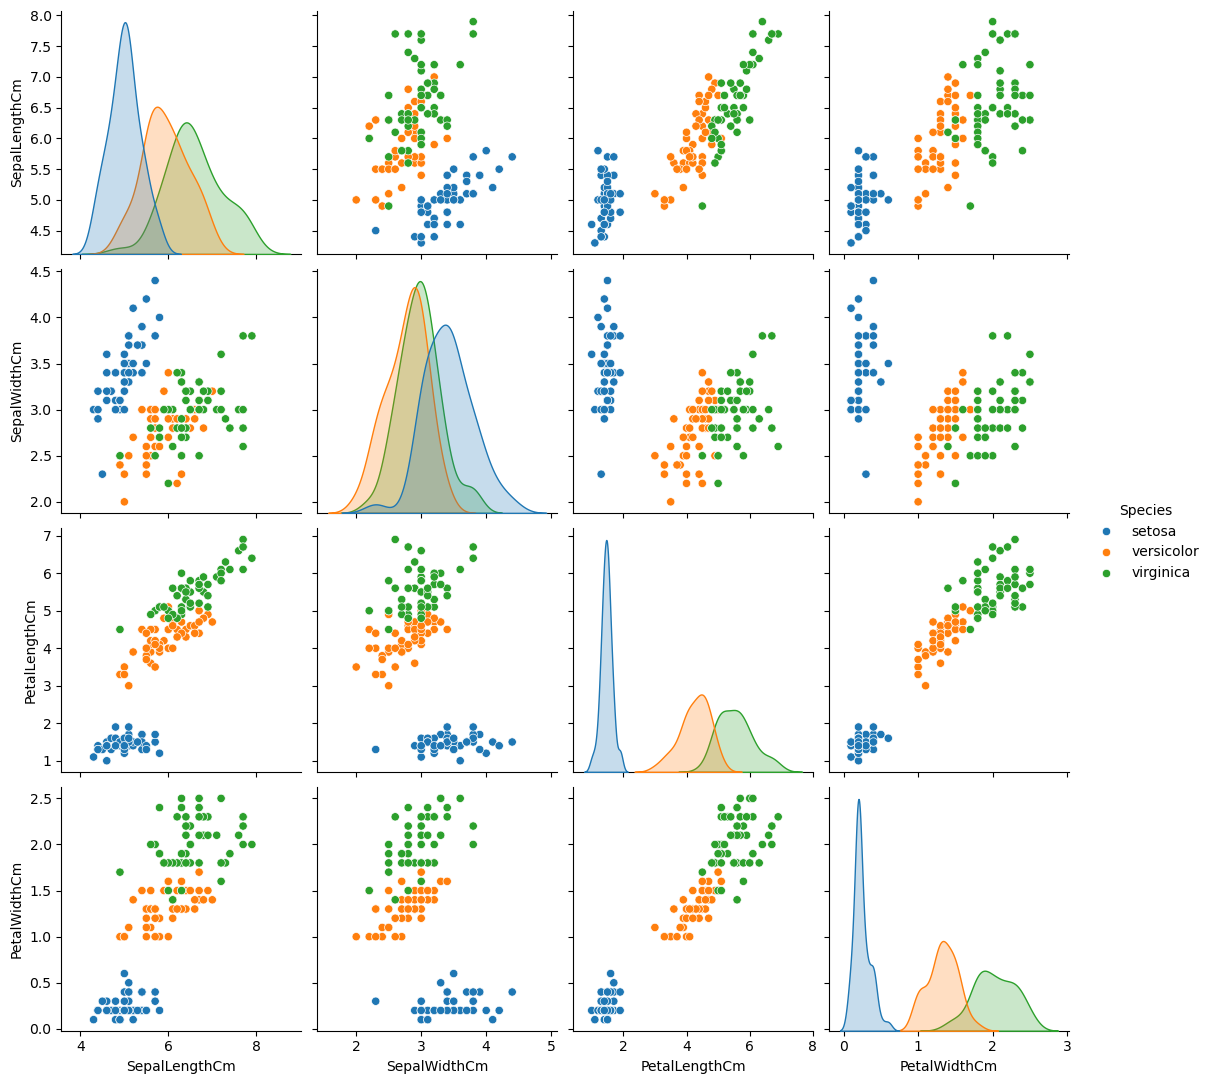

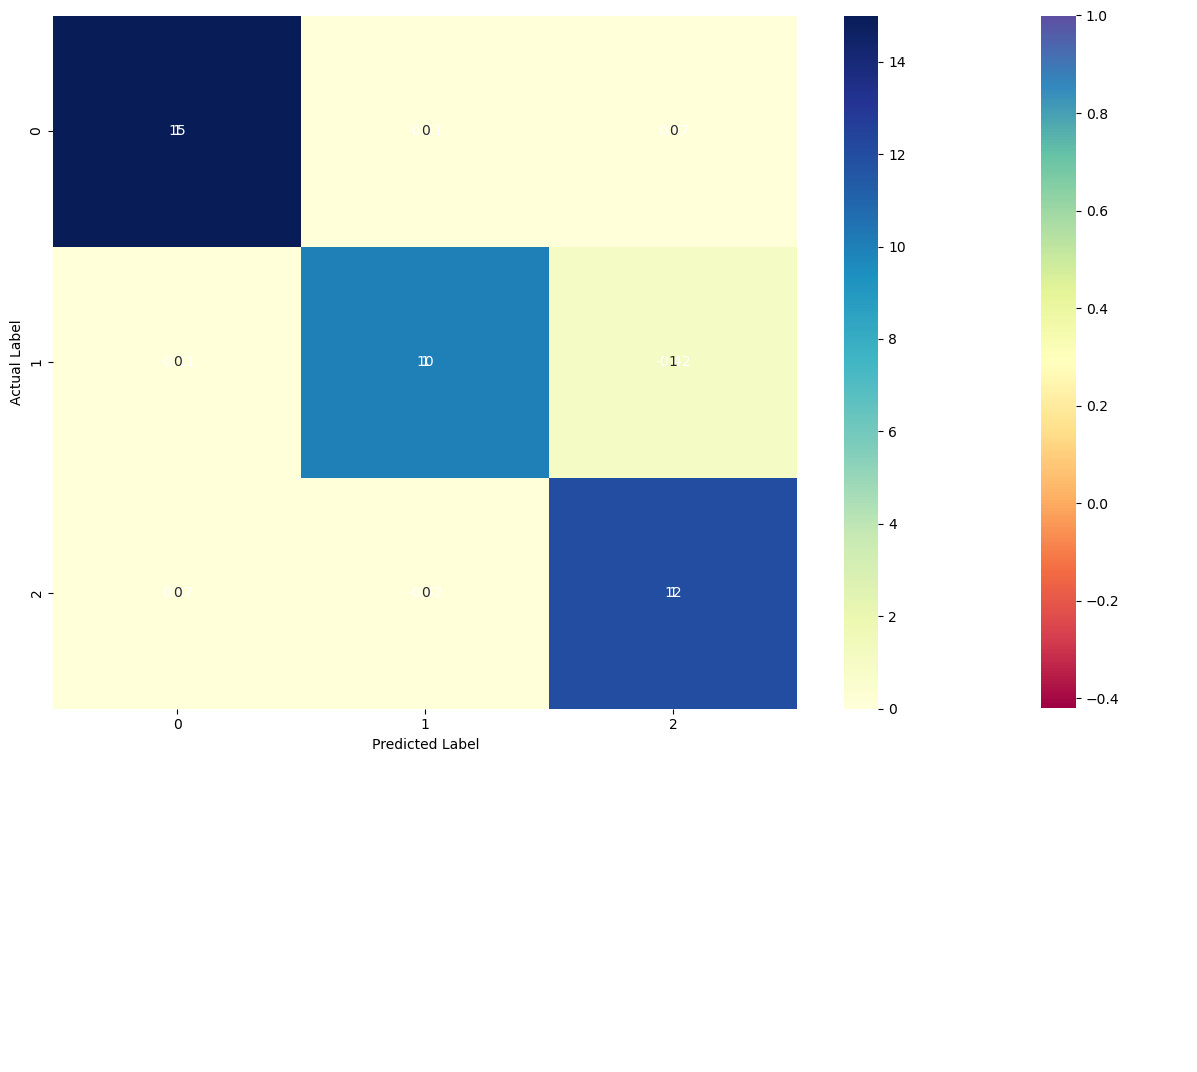

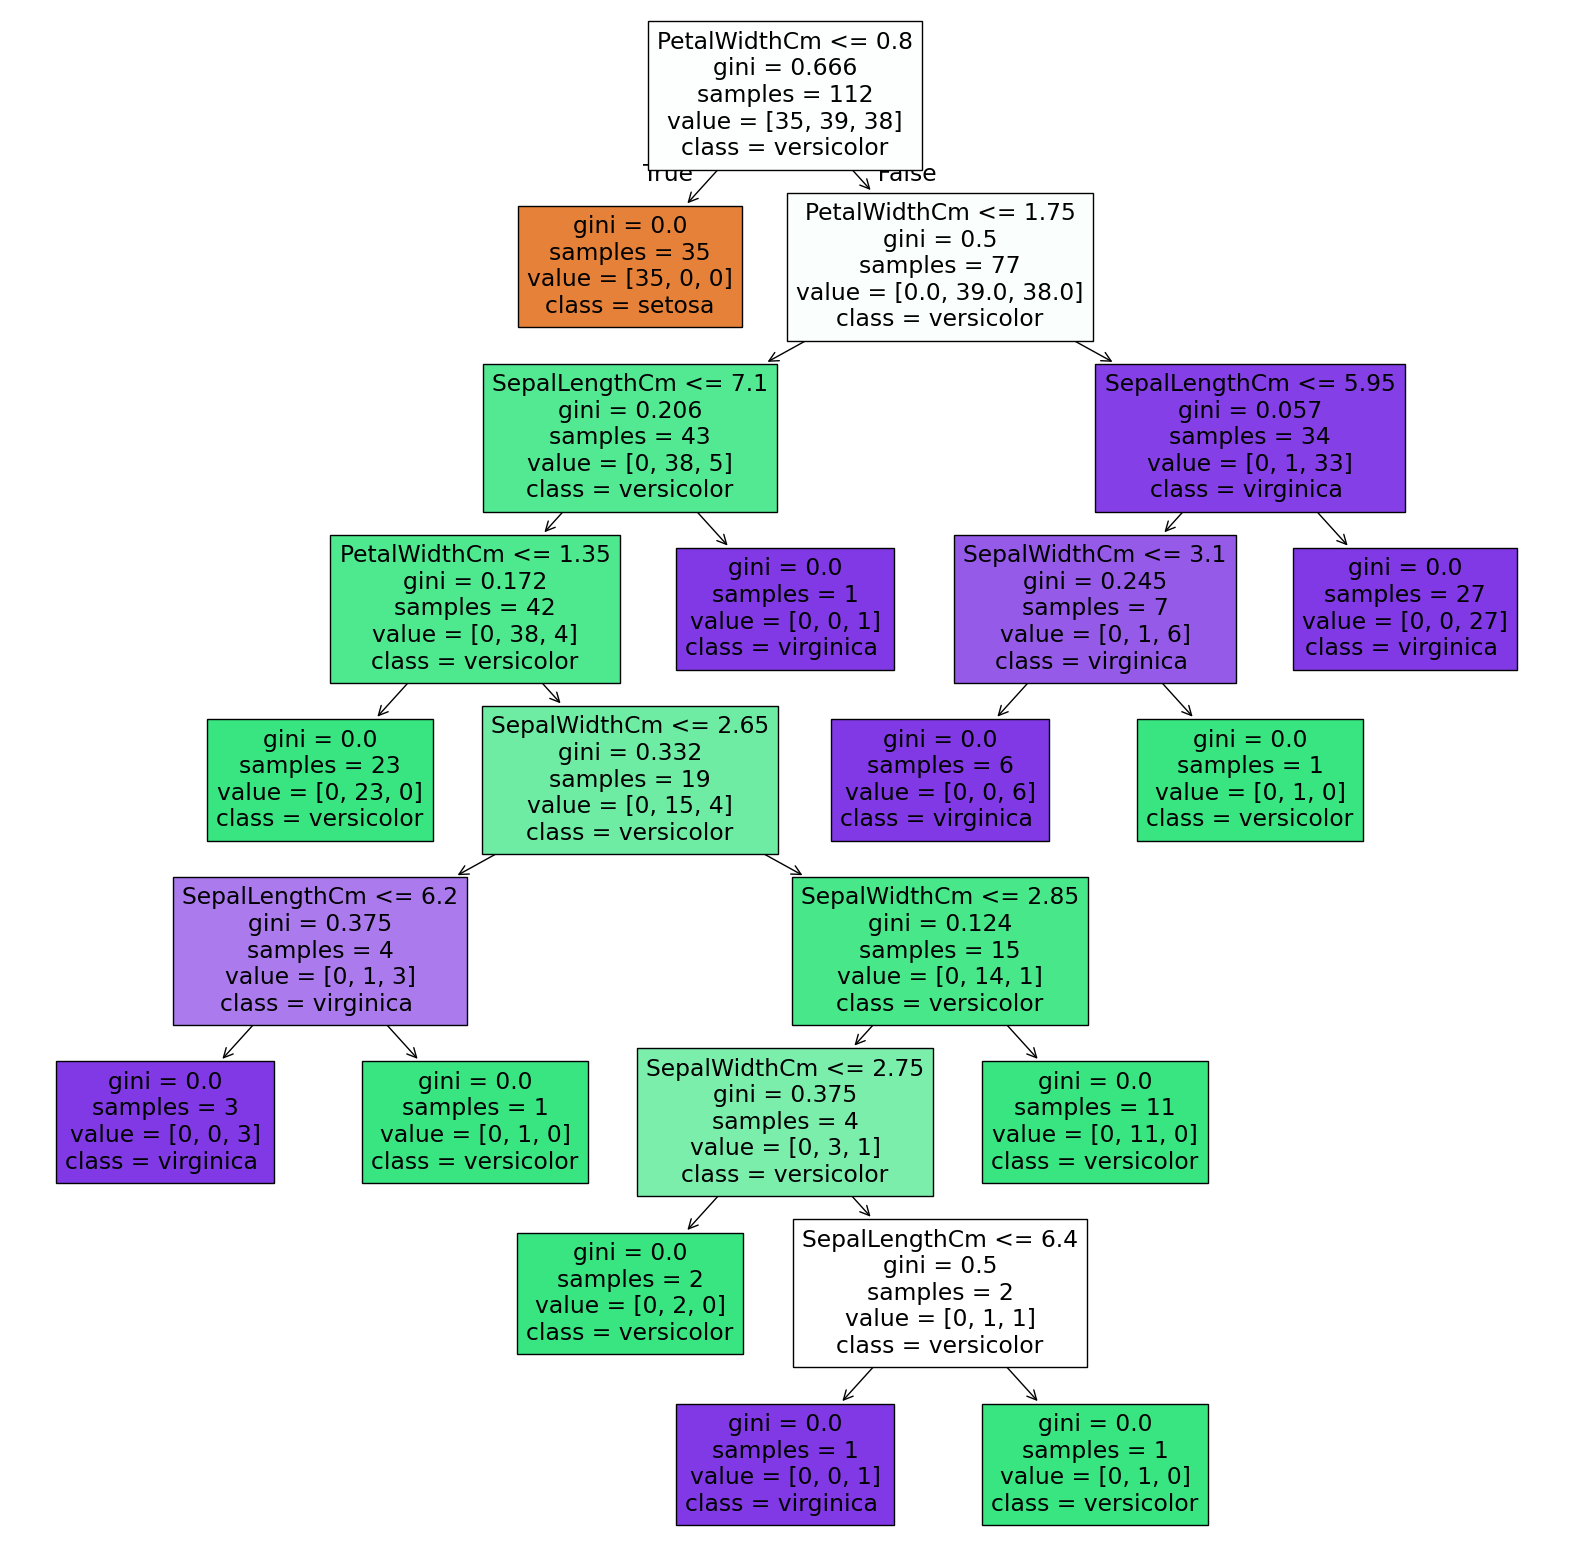

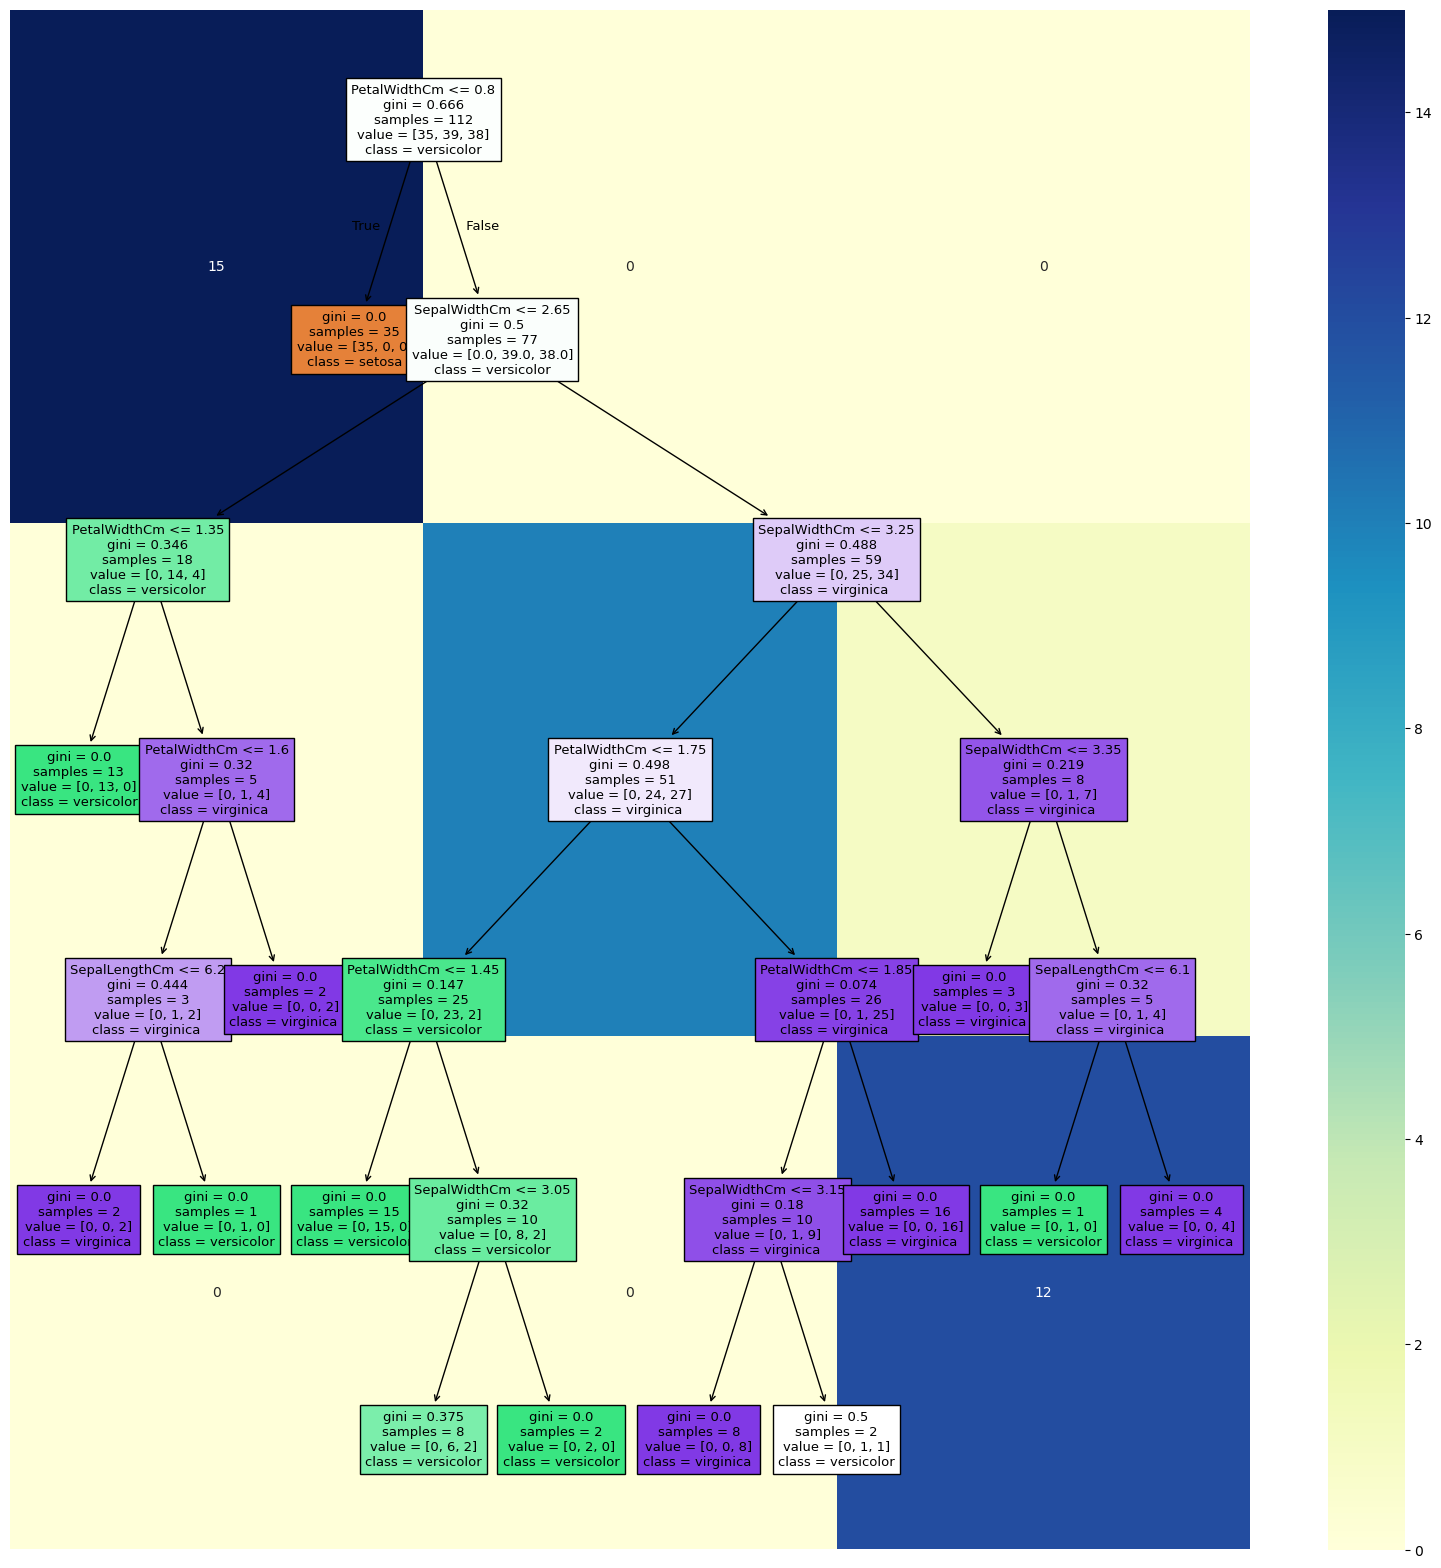

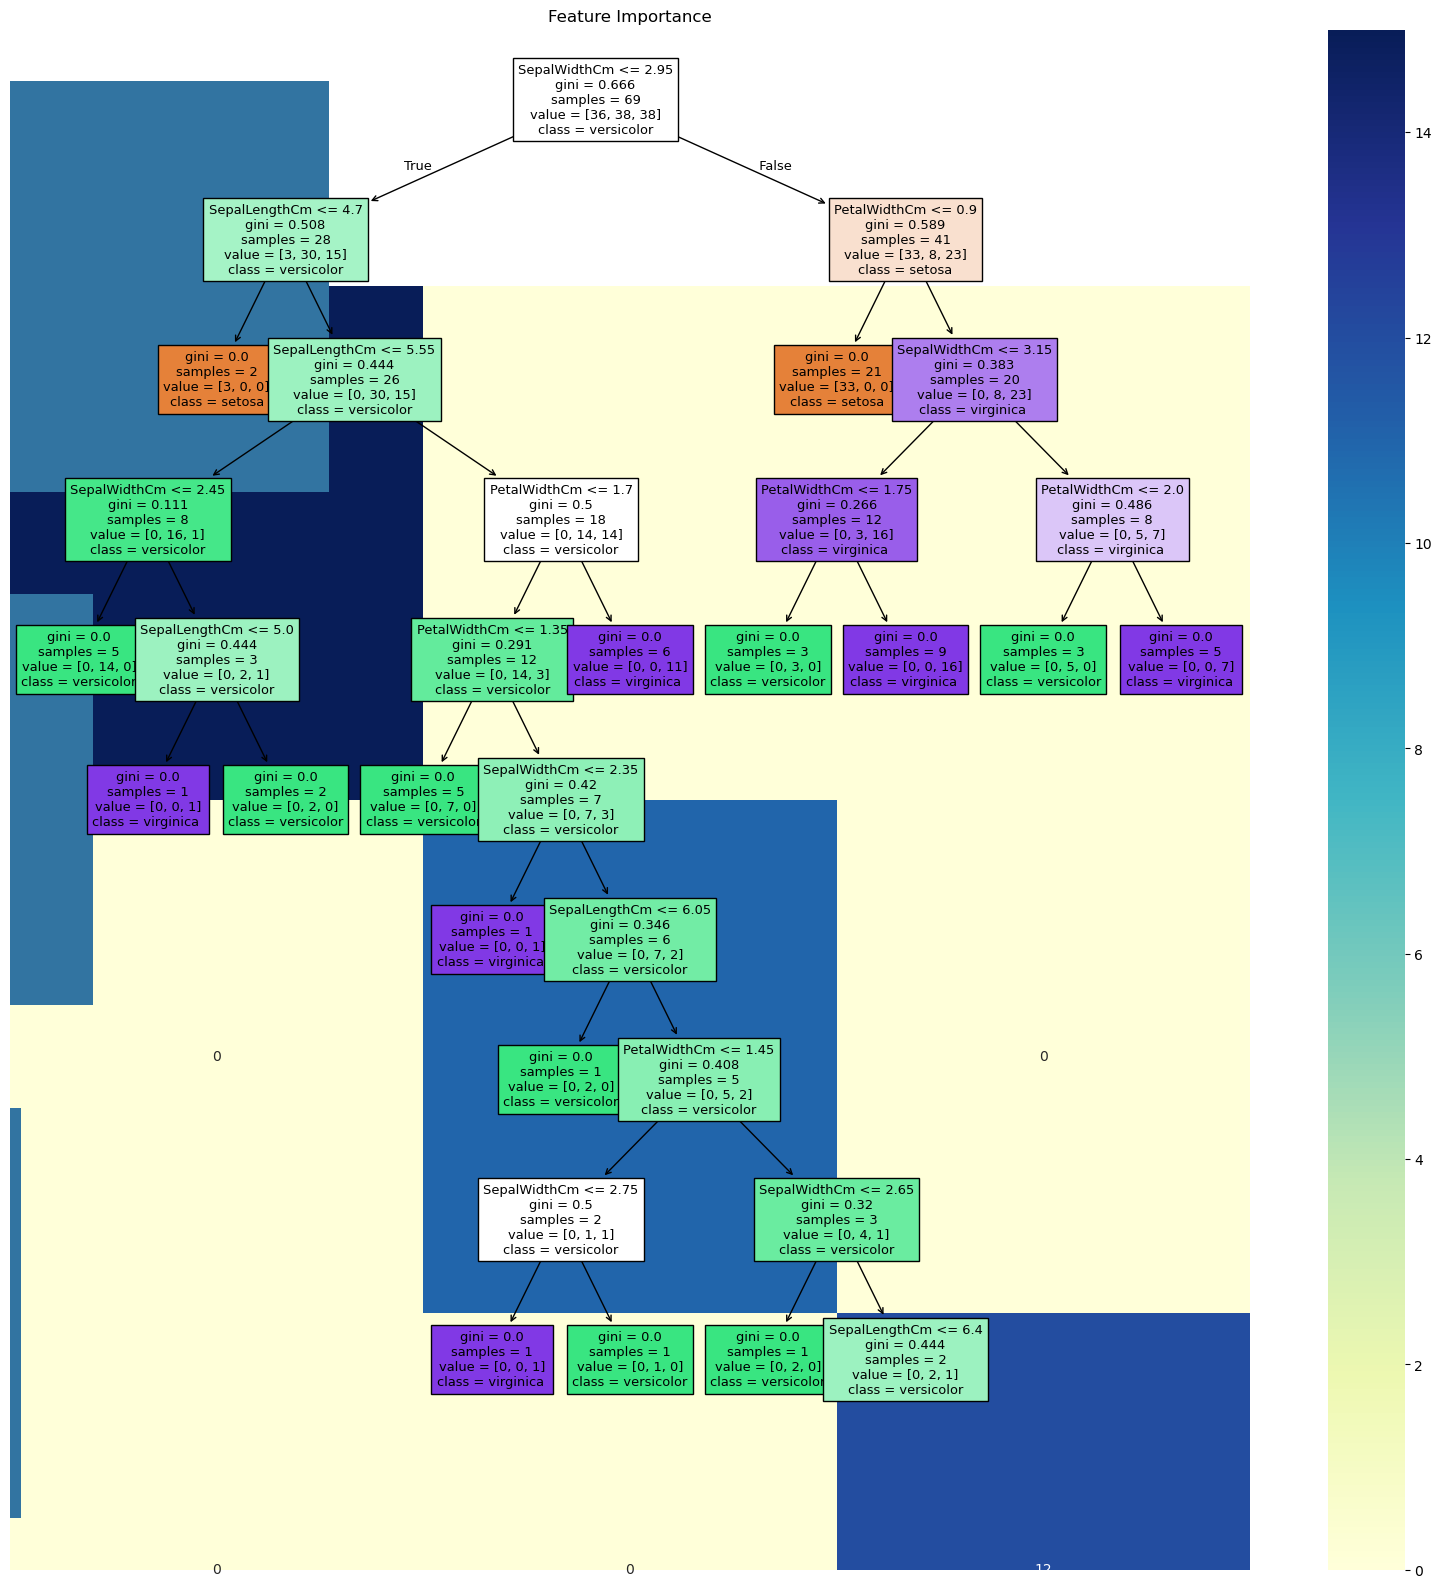

In [79]:
sns.barplot(x = best_features, y = best_features.index)
plt.title("Feature Importance")
plt.show()

**Random Forest Modelling**

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
rf_model = RandomForestClassifier()

In [82]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_pred = rf_model.predict(X_test)

In [84]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9736842105263158


In [85]:
cv_scores = cross_val_score(estimator=rf_model, X=X_train, y=y_train, cv=10)
cv_scores.mean()

np.float64(0.9098484848484848)

In [86]:
print(confusion_matrix(y_test, y_pred))

[[15  0  0]
 [ 0 10  1]
 [ 0  0 12]]


In [87]:
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_matrix, annot=True, cmap="YlGnBu")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

Text(0.5, 23.52222222222222, 'Predicted Label')

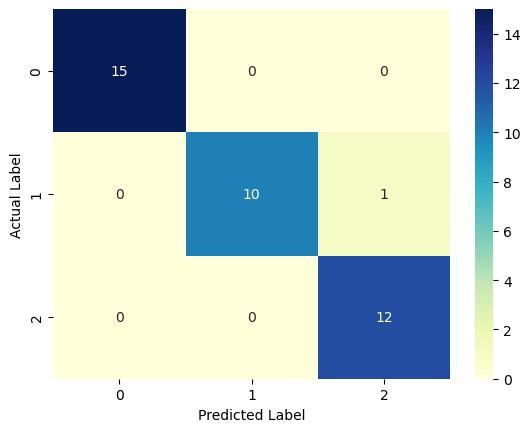

In [88]:
plt.show()

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.91      0.95        11
   virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [90]:
rf_model.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=867159264),
 DecisionTreeClassifier(max_features='sqrt', random_state=1247585665),
 DecisionTreeClassifier(max_features='sqrt', random_state=1763782574),
 DecisionTreeClassifier(max_features='sqrt', random_state=34947411),
 DecisionTreeClassifier(max_features='sqrt', random_state=10735942),
 DecisionTreeClassifier(max_features='sqrt', random_state=748195794),
 DecisionTreeClassifier(max_features='sqrt', random_state=1200464412),
 DecisionTreeClassifier(max_features='sqrt', random_state=637714437),
 DecisionTreeClassifier(max_features='sqrt', random_state=1330390502),
 DecisionTreeClassifier(max_features='sqrt', random_state=245266061),
 DecisionTreeClassifier(max_features='sqrt', random_state=2145444507),
 DecisionTreeClassifier(max_features='sqrt', random_state=790237523),
 DecisionTreeClassifier(max_features='sqrt', random_state=889623015),
 DecisionTreeClassifier(max_features='sqrt', random_state=1631245016),
 DecisionTreeCla

In [94]:
plt.figure(figsize=(20,20)) 
tree2 = tree.plot_tree(rf_model.estimators_[0], filled=True, feature_names=features , class_names = targets)

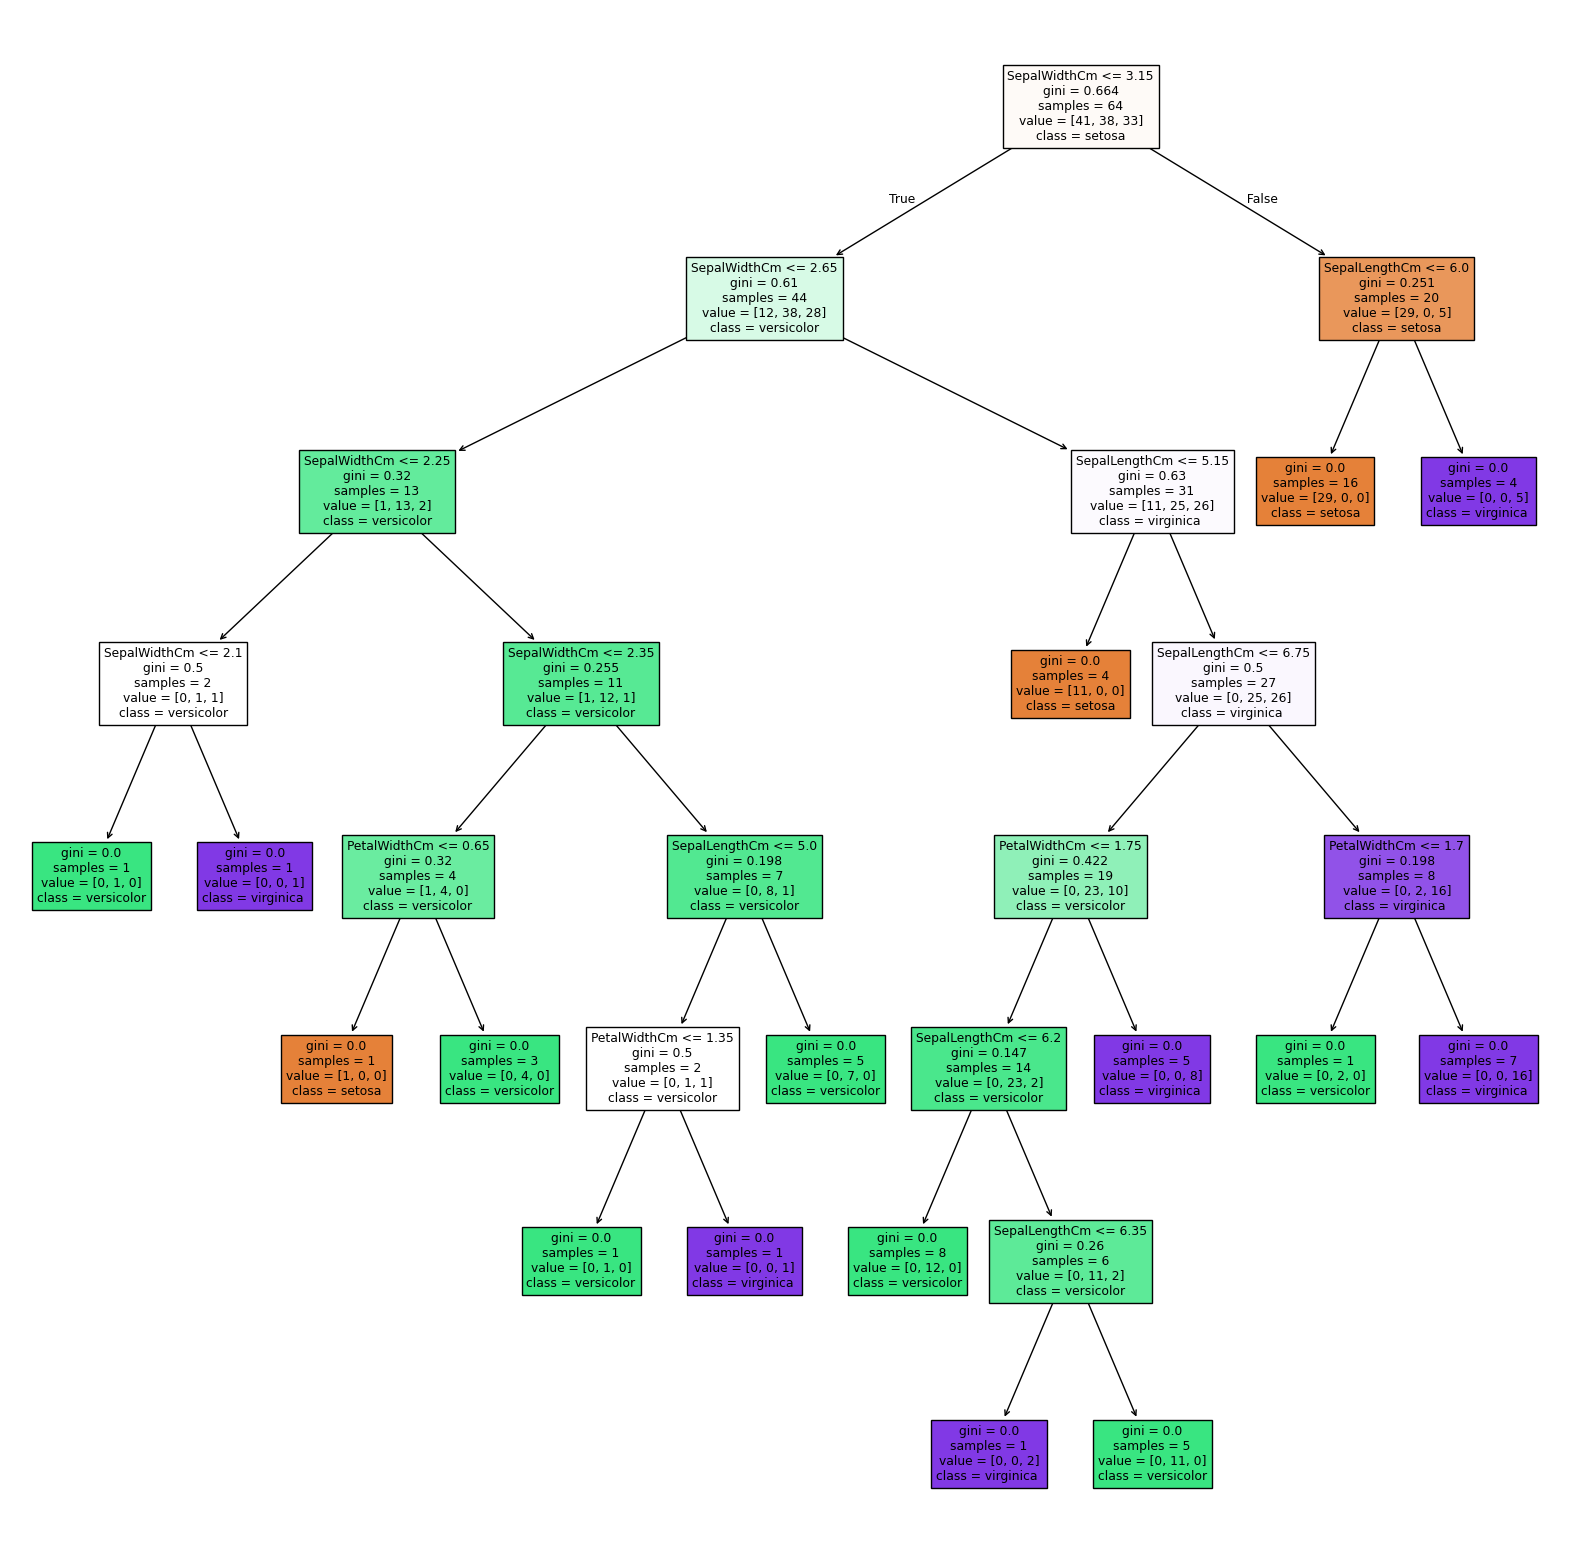

In [95]:
plt.show()

**Hyperparameter Optimization with Python**

In [97]:
rf_model2 = RandomForestClassifier()

In [103]:
rf_params = {
    "n_estimators":[50,100,300],
    "max_depth":[3,5,7],
    "max_features":[2,4,6,8],
    "min_samples_split": [2,4,6]
}

In [104]:
rf_cv_model = GridSearchCV(rf_model2, rf_params, cv = 5, n_jobs=-1)

In [105]:
rf_cv_model.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [2, 4, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [106]:
rf_cv_model.best_params_

{'max_depth': 3, 'max_features': 2, 'min_samples_split': 2, 'n_estimators': 50}

In [107]:
rf_tuned = RandomForestClassifier(
    max_depth=3,
    max_features=2,
    min_samples_split=2,
    n_estimators=50
)

In [108]:
rf_tuned.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
y_pred = rf_tuned.predict(X_test)

In [111]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


In [112]:
print(confusion_matrix(y_test, y_pred))

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [113]:
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_matrix, annot=True, cmap="YlGnBu")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

Text(0.5, 23.52222222222222, 'Predicted Label')

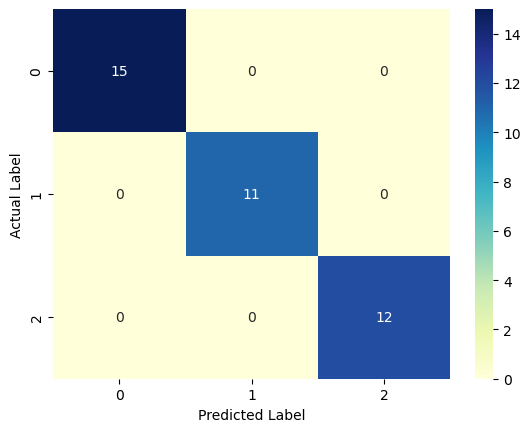

In [114]:
plt.show()

In [115]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [116]:
rf_tuned.feature_importances_

array([0.18829795, 0.0479869 , 0.76371515])

In [118]:
X_train.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalWidthCm'], dtype='object')

In [120]:
best_features = pd.Series(rf_tuned.feature_importances_,
    index=X_train.columns).sort_values(ascending=False)

In [121]:
best_features

PetalWidthCm     0.763715
SepalLengthCm    0.188298
SepalWidthCm     0.047987
dtype: float64

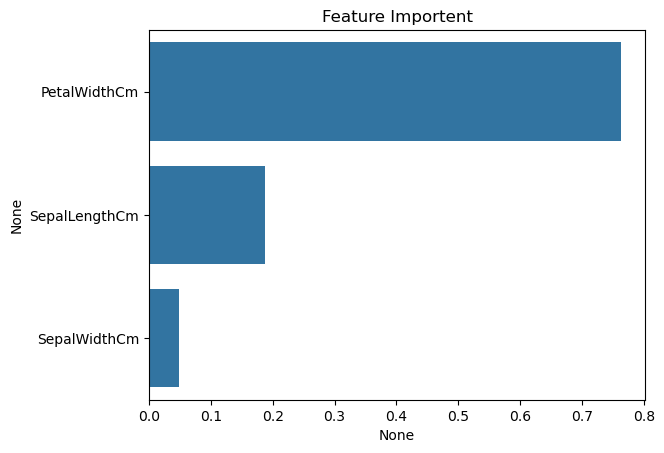

In [122]:
sns.barplot(x=best_features, y = best_features.index)
plt.title("Feature Importent")
plt.show()